# Resonator spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal03_resonator_spectroscopy import ResonatorSpectroscopy

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # Use None if no flux bias needed
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None if param persisting is not required
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "resonator_spectroscopy"

QUBITS = ["q1"]
FREQUENCY_CENTER = None  # None: use each qubit's own readout frequency from the device config
FREQUENCY_WIDTH = 20e6
FREQUENCY_POINTS = 201
REPETITIONS = 100

READOUT_AMPLITUDE = 0.08
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    repetitions=REPETITIONS,
    readout_amplitude=READOUT_AMPLITUDE,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 6kB
Dimensions:           (acq_index_S21_q1: 201)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 2kB 6.045e+09 ... 6.065e+09
  * acq_index_S21_q1  (acq_index_S21_q1) int64 2kB 0 1 2 3 4 ... 197 198 199 200
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 3kB (0.002818571802377700...
Attributes:
    tuid:     20260916-021900-230-690873

## Optional: Simulated data

In [5]:
# dataset = experiment.simulated_data(
#     frequency_center=7.5e9,
#     frequency_width=40e6,
#     frequency_points=401,
#     resonance_frequency=7.495e9,
#     loaded_quality_factor=8_000,
#     coupling_quality_factor=12_000,
#     signal_amplitude=1.0,
#     noise=0.01,
#     electrical_delay=20e-9,
#     phase_offset=0.0,
#     asymmetry=0.0,
#     seed=42,
# )
# dataset

## Analysis

In [6]:
results = experiment.analysis()

for qubit, result in results.items():
    print(
        f"{qubit}: success={result.success}, "
        f"fr={result.frequency / 1e9:.9f} GHz, "
        f"Qi={result.internal_quality_factor:.3g}, "
        f"Qc={result.coupling_quality_factor:.3g}"
    )

q1: success=True, fr=6.055479547 GHz, Qi=8.58e+03, Qc=1.87e+03


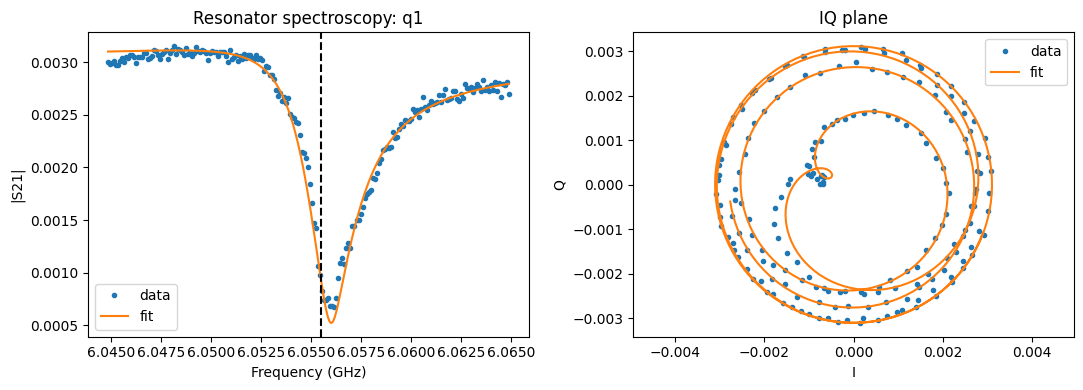

In [7]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [9]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [8]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [24]:
from qcodes.instrument import Instrument

Instrument.close_all()